In [2]:
# Instalando os pacotes das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    roc_auc_score, 
    roc_curve,
    confusion_matrix, 
    f1_score, 
    precision_score, 
    recall_score
)

Carregando dados processados...

[Treinamento] Ajustando o Random Forest...

=== RESULTADOS DO RANDOM FOREST ===
Acurácia:  0.5919
AUC-ROC:   0.6170
F1-Score:  0.4916
Precisão:  0.4371
Recall:    0.5616

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.72      0.61      0.66       914
           1       0.44      0.56      0.49       495

    accuracy                           0.59      1409
   macro avg       0.58      0.58      0.58      1409
weighted avg       0.62      0.59      0.60      1409



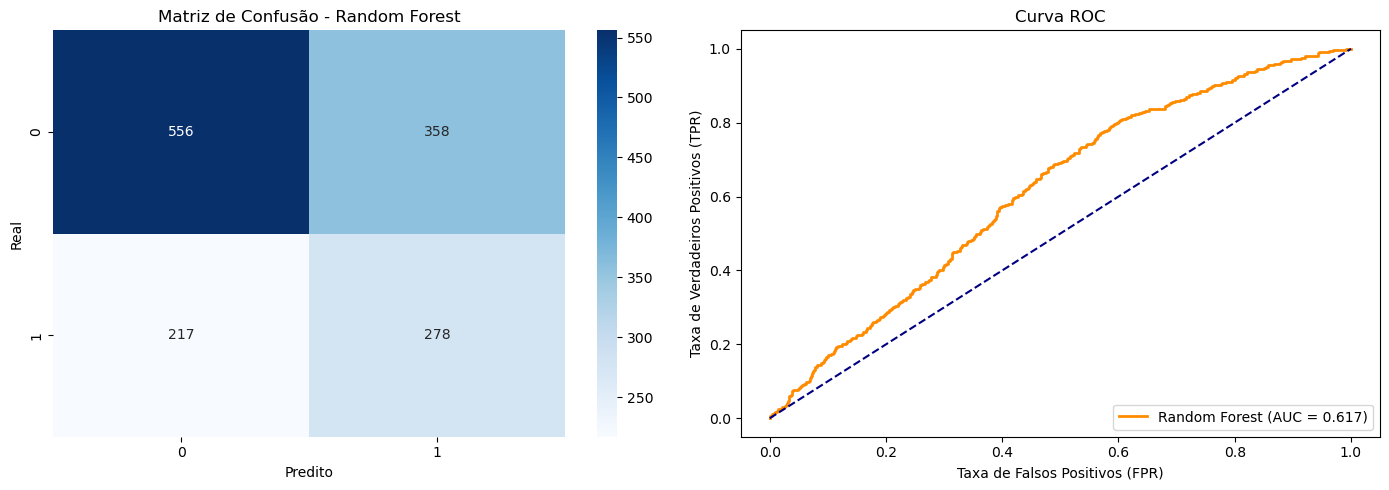

C:\Users\eduardo.sepulveda\AppData\Local\Temp\ipykernel_29376\2708725614.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


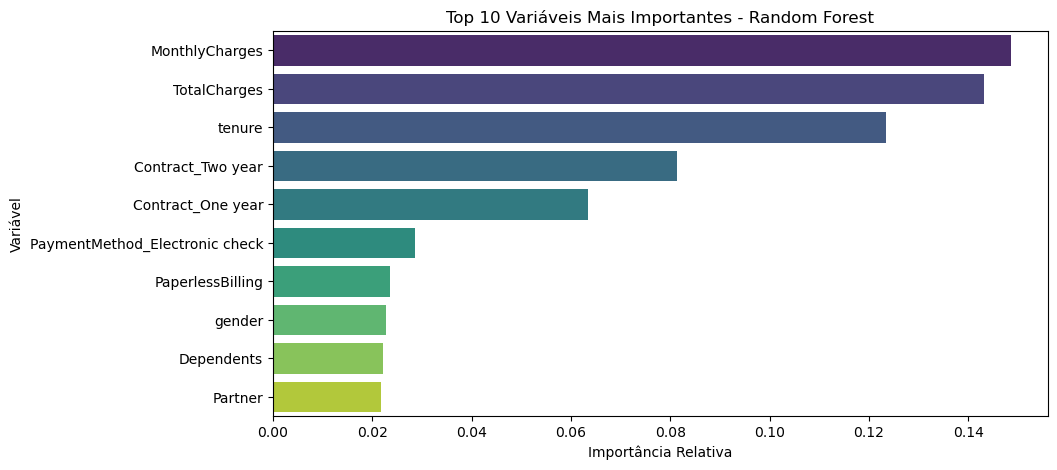

Modelo salvo com sucesso em: ../models/random_forest_model.joblib


In [3]:
# 1. Carregar os dados processados
print("Carregando dados processados...")
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# 2. Treinar o Random Forest com balanceamento de classe
print('\n[Treinamento] Ajustando o Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)  # Corrigido y-train para y_train

# 3. Avaliação do Modelo
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print('\n=== RESULTADOS DO RANDOM FOREST ===')
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

# 4. Matriz de Confusão e Curva ROC
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão - Random Forest')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})', color='darkorange', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
ax[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax[1].set_title('Curva ROC')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 5. Importância das Variáveis (Feature Importance)
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_10 = feature_importances.nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')
plt.title('Top 10 Variáveis Mais Importantes - Random Forest')
plt.xlabel('Importância Relativa')
plt.ylabel('Variável')
plt.show()

# 6. Salvar o Modelo Treinado
pasta_modelos = '../models/'
os.makedirs(pasta_modelos, exist_ok=True)
caminho_modelo = os.path.join(pasta_modelos, 'random_forest_model.joblib')
joblib.dump(rf_model, caminho_modelo)
print(f"Modelo salvo com sucesso em: {caminho_modelo}")